In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
df= pd.read_csv("logistic regression dataset-Social_Network_Ads.csv")

In [36]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [37]:
df.drop('User ID',axis=1,inplace=True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   EstimatedSalary  400 non-null    int64 
 3   Purchased        400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB


In [39]:
df.isnull().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Age                   Axes(0.125,0.11;0.227941x0.77)
EstimatedSalary    Axes(0.398529,0.11;0.227941x0.77)
Purchased          Axes(0.672059,0.11;0.227941x0.77)
dtype: object

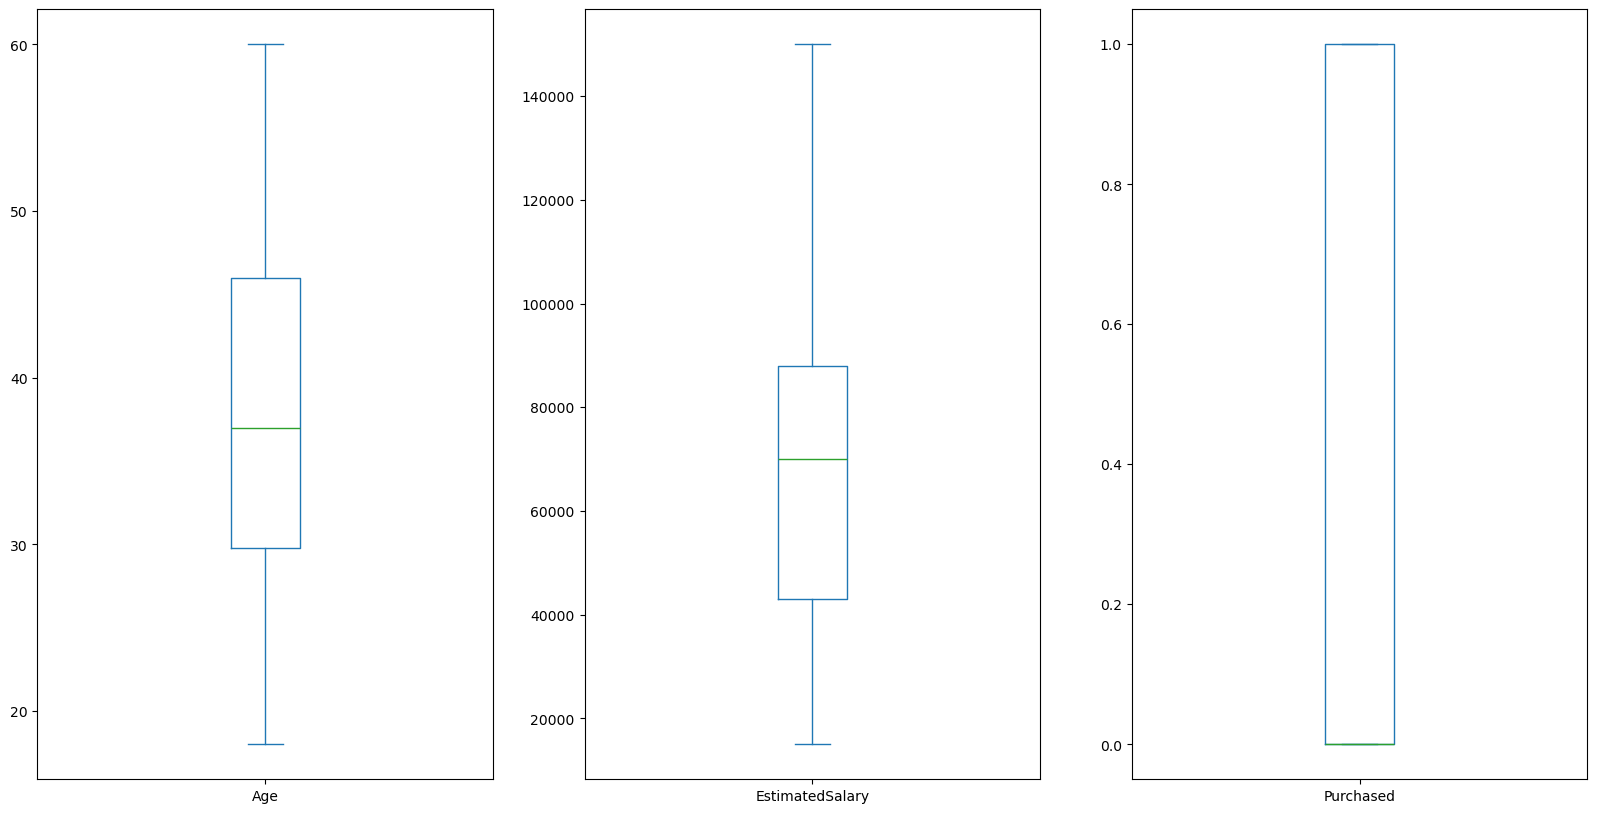

In [40]:
df.plot(kind="box",subplots=True,sharey=False,figsize=(20,10))

In [41]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [42]:
from  sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Gender'] 


0      1
1      1
2      0
3      0
4      1
      ..
395    0
396    1
397    0
398    1
399    0
Name: Gender, Length: 400, dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           400 non-null    int64
 1   Age              400 non-null    int64
 2   EstimatedSalary  400 non-null    int64
 3   Purchased        400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


In [44]:
x = df.drop('Purchased',axis=1)
y = df['Purchased']

In [45]:
x

,Gender,Age,EstimatedSalary
0,1,19,19000
1,1,35,20000
2,0,26,43000
3,0,27,57000
4,1,19,76000
...,...,...,...
395,0,46,41000
396,1,51,23000
397,0,50,20000
398,1,36,33000


In [46]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [47]:
from numpy._core.defchararray import count
count=df['Purchased'].value_counts()
count

Purchased
0    257
1    143
Name: count, dtype: int64

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)


In [49]:
x_train

,Gender,Age,EstimatedSalary
3,0,27,57000
18,1,46,28000
202,0,39,134000
250,0,44,39000
274,0,57,26000
...,...,...,...
71,0,24,27000
106,0,26,35000
270,0,43,133000
348,1,39,77000


In [50]:
x_test

,Gender,Age,EstimatedSalary
209,0,46,22000
280,0,59,88000
33,0,28,44000
210,0,48,96000
93,0,29,28000
...,...,...,...
246,0,35,50000
227,1,56,133000
369,0,54,26000
176,0,35,47000


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [52]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()

In [53]:
print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("After SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {0: 205, 1: 115}
After SMOTE: {0: 205, 1: 205}


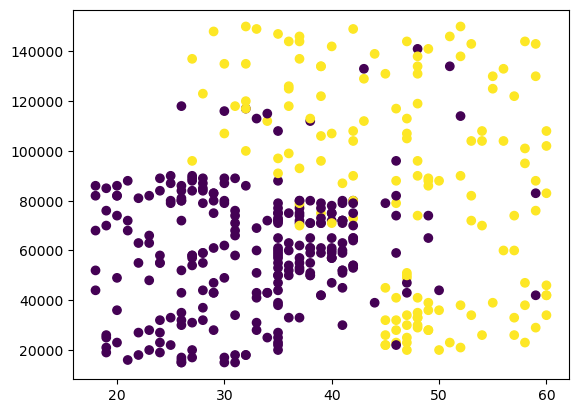

In [54]:
plt.scatter(df['Age'], df['EstimatedSalary'], c=df['Purchased'])

In [55]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [56]:
lr.fit(x_train_smote, y_train_smote)

LogisticRegression()

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

y_pred = lr.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8875

Confusion Matrix:
 [[47  5]
 [ 4 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91        52
           1       0.83      0.86      0.84        28

    accuracy                           0.89        80
   macro avg       0.87      0.88      0.88        80
weighted avg       0.89      0.89      0.89        80



In [58]:
y_prob = lr.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

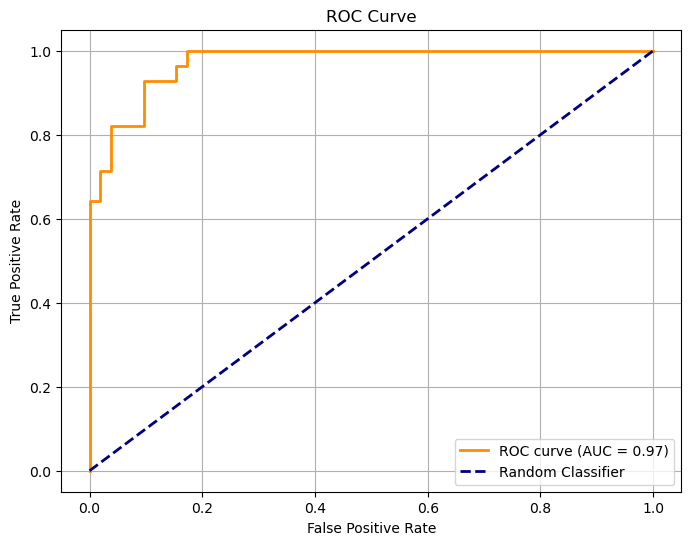

In [59]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
threshold = 0.4
y_pred_thresh = (y_prob >= threshold).astype(int)
print(f"\nClassification Report at threshold={threshold}:\n")
print(classification_report(y_test, y_pred_thresh))


Classification Report at threshold=0.4:

              precision    recall  f1-score   support

           0       0.96      0.88      0.92        52
           1       0.81      0.93      0.87        28

    accuracy                           0.90        80
   macro avg       0.89      0.91      0.89        80
weighted avg       0.91      0.90      0.90        80

